# Text Classification with RNNs: Vanilla RNN vs LSTM vs GRU
### IMDB Sentiment Analysis — Binary Classification (Positive / Negative)
> Bidirectional recurrent architectures with Dropout, trained on GPU.

## 1. Install & Import Dependencies

In [1]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device — automatically uses GPU if available ─────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Memory: 8.6 GB


## 2. Hyperparameters

In [2]:
# ── Hyperparameters — tuned for GPU training ──────────────────────────────────
VOCAB_SIZE    = 10_000   # top-10k most frequent tokens
EMBED_DIM     = 100      # embedding dimensionality
HIDDEN_DIM    = 128      # hidden state size per direction
NUM_LAYERS    = 2        # stacked recurrent layers (2 → richer representations)
DROPOUT       = 0.3      # dropout probability (applied between layers & on embeddings)
BIDIRECTIONAL = True     # True → model reads sequence forward AND backward
BATCH_SIZE    = 128      # larger batch = better GPU utilization
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 20       # more epochs since GPU is available
MAX_LEN       = 256
PAD_IDX       = 0
UNK_IDX       = 1

# Output dim of FC layer = hidden_dim * 2 if bidirectional, else hidden_dim
FC_INPUT_DIM  = HIDDEN_DIM * 2 if BIDIRECTIONAL else HIDDEN_DIM

print('Hyperparameters set.')
print(f'  Bidirectional  : {BIDIRECTIONAL}')
print(f'  Dropout        : {DROPOUT}')
print(f'  FC input dim   : {FC_INPUT_DIM}  (hidden_dim x 2 because bidirectional)')

Hyperparameters set.
  Bidirectional  : True
  Dropout        : 0.3
  FC input dim   : 256  (hidden_dim x 2 because bidirectional)


## 3. Load the IMDB Dataset

In [3]:
# Using keras.datasets for a simple, lightweight download (no torchtext auth required)
from tensorflow.keras.datasets import imdb as keras_imdb  # type: ignore

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras_imdb.load_data(
    num_words=VOCAB_SIZE
)

print(f'Train samples : {len(x_train_raw)}')
print(f'Test  samples : {len(x_test_raw)}')
print(f'Label balance (train) — pos: {y_train_raw.sum()}, neg: {len(y_train_raw) - y_train_raw.sum()}')

Train samples : 25000
Test  samples : 25000
Label balance (train) — pos: 12500, neg: 12500


## 4. Data Preprocessing — Padding & Truncation

x_train shape: (25000, 256)
x_test  shape: (25000, 256)


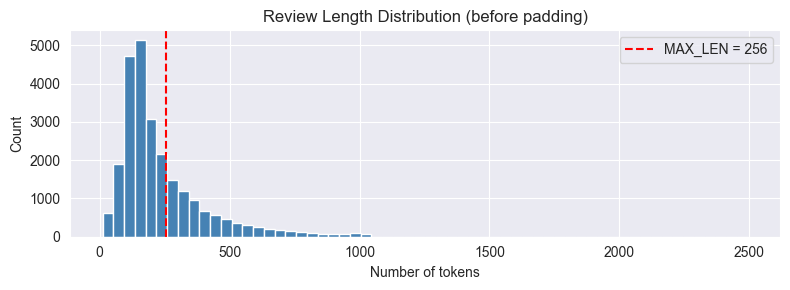

In [4]:
def pad_sequence(seq, max_len, pad_value=PAD_IDX):
    """Truncate to max_len or right-pad with pad_value."""
    seq = list(seq)[:max_len]
    seq += [pad_value] * (max_len - len(seq))
    return seq

x_train = np.array([pad_sequence(s, MAX_LEN) for s in x_train_raw], dtype=np.int64)
x_test  = np.array([pad_sequence(s, MAX_LEN) for s in x_test_raw],  dtype=np.int64)
y_train = y_train_raw.astype(np.float32)
y_test  = y_test_raw.astype(np.float32)

print(f'x_train shape: {x_train.shape}')   # (25000, 256)
print(f'x_test  shape: {x_test.shape}')    # (25000, 256)

# Review length distribution
raw_lengths = [len(s) for s in x_train_raw]
plt.figure(figsize=(8, 3))
plt.hist(raw_lengths, bins=60, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
plt.title('Review Length Distribution (before padding)')
plt.xlabel('Number of tokens'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()

## 5. PyTorch Dataset & DataLoaders

In [5]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = torch.tensor(texts,  dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):              return len(self.labels)
    def __getitem__(self, idx):     return self.texts[idx], self.labels[idx]


train_dataset = IMDBDataset(x_train, y_train)
test_dataset  = IMDBDataset(x_test,  y_test)

# pin_memory=True speeds up CPU→GPU data transfer
PIN = (DEVICE.type == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=PIN)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 196
Test  batches : 196


## 6. Model Definitions — Bidirectional RNN / LSTM / GRU with Dropout

**Key improvements over baseline:**
- `bidirectional=True` — the model reads each review both left→right and right→left, then concatenates both hidden states. This captures context from both directions.
- `dropout` on the embedding output — randomly zeros token vectors during training, acting as regularization.
- `dropout` between RNN layers — PyTorch applies this automatically when `num_layers > 1`.
- `num_layers=2` — stacked recurrent layers learn more abstract features.

In [6]:
class SentimentClassifier(nn.Module):
    """
    Bidirectional recurrent classifier with Dropout.
    Architecture: Embedding → Dropout → BiRNN/BiLSTM/BiGRU → FC → Sigmoid
    """
    def __init__(self, rnn_type: str,
                 vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                 dropout=DROPOUT, bidirectional=BIDIRECTIONAL,
                 pad_idx=PAD_IDX):
        super().__init__()
        self.rnn_type     = rnn_type.upper()
        self.bidirectional = bidirectional

        # 1. Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 2. Dropout on embedding output
        self.embed_dropout = nn.Dropout(dropout)

        # 3. Recurrent layer (bidirectional, multi-layer)
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[self.rnn_type]
        self.rnn = rnn_cls(
            input_size   = embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            dropout      = dropout if num_layers > 1 else 0,  # between layers only
            bidirectional= bidirectional
        )

        # 4. Dropout before FC
        self.fc_dropout = nn.Dropout(dropout)

        # 5. Fully connected + sigmoid
        fc_in = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc      = nn.Linear(fc_in, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embed_dropout(self.embedding(x))   # (batch, seq_len, embed_dim)

        if self.rnn_type == 'LSTM':
            _, (hidden, _) = self.rnn(embedded)  # hidden: (num_layers*dirs, batch, hidden_dim)
        else:
            _, hidden = self.rnn(embedded)

        if self.bidirectional:
            # Concatenate last forward and last backward hidden states
            # hidden[-2] = last forward layer, hidden[-1] = last backward layer
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, hidden_dim*2)
        else:
            last_hidden = hidden[-1]   # (batch, hidden_dim)

        out = self.fc_dropout(last_hidden)
        return self.sigmoid(self.fc(out)).squeeze(1)   # (batch,)


# Instantiate all three models and move to GPU
models = {
    'RNN' : SentimentClassifier('RNN').to(DEVICE),
    'LSTM': SentimentClassifier('LSTM').to(DEVICE),
    'GRU' : SentimentClassifier('GRU').to(DEVICE),
}

for name, model in models.items():
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name:4s}  trainable params: {n:,}')

RNN   trainable params: 1,157,953
LSTM  trainable params: 1,631,041
GRU   trainable params: 1,473,345


## 7. Training & Evaluation Helper Functions

In [7]:
def train_epoch(model, loader, optimizer, criterion):
    """One full pass over training set. Returns avg loss & accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for texts, labels in loader:
        texts, labels = texts.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        preds = model(texts)
        loss  = criterion(preds, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients (especially helps Vanilla RNN)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += ((preds >= 0.5) == labels.bool()).sum().item()
        total      += len(labels)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate on any DataLoader. Returns loss, accuracy, preds, labels."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(DEVICE), labels.to(DEVICE)
            preds     = model(texts)
            loss      = criterion(preds, labels)
            predicted = (preds >= 0.5).long()

            total_loss += loss.item() * len(labels)
            correct    += (predicted == labels.long()).sum().item()
            total      += len(labels)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().long().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


print('Helper functions defined.')

Helper functions defined.


## 8. Train All Three Models

In [8]:
criterion  = nn.BCELoss()
history    = {n: {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
              for n in models}
optimizers = {n: torch.optim.Adam(m.parameters(), lr=LEARNING_RATE)
              for n, m in models.items()}

# ReduceLROnPlateau: halve LR if val_loss doesn't improve for 2 epochs
schedulers = {n: torch.optim.lr_scheduler.ReduceLROnPlateau(
                  opt, mode='min', factor=0.5, patience=2)
              for n, opt in optimizers.items()}

for name, model in models.items():
    print(f'\n{"="*55}')
    print(f'  Training  Bi-{name}  (dropout={DROPOUT}, layers={NUM_LAYERS})')
    print(f'{"="*55}')
    opt, sched = optimizers[name], schedulers[name]
    t0 = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc        = train_epoch(model, train_loader, opt, criterion)
        va_loss, va_acc, _, _  = evaluate(model, test_loader, criterion)
        sched.step(va_loss)   # adjust LR based on validation loss

        history[name]['train_loss'].append(tr_loss)
        history[name]['train_acc'].append(tr_acc)
        history[name]['val_loss'].append(va_loss)
        history[name]['val_acc'].append(va_acc)

        print(f'  Epoch {epoch:2d}/{NUM_EPOCHS} | '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
              f'Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f}')

    print(f'  Done in {time.time()-t0:.1f}s')


  Training  Bi-RNN  (dropout=0.3, layers=2)
  Epoch  1/20 | Train Loss: 0.6901  Acc: 0.5464 | Val Loss: 0.6985  Acc: 0.5322
  Epoch  2/20 | Train Loss: 0.6722  Acc: 0.5866 | Val Loss: 0.6828  Acc: 0.5739
  Epoch  3/20 | Train Loss: 0.6600  Acc: 0.6172 | Val Loss: 0.6970  Acc: 0.5984
  Epoch  4/20 | Train Loss: 0.6336  Acc: 0.6476 | Val Loss: 0.6377  Acc: 0.6447
  Epoch  5/20 | Train Loss: 0.6209  Acc: 0.6671 | Val Loss: 0.6118  Acc: 0.6873
  Epoch  6/20 | Train Loss: 0.6299  Acc: 0.6566 | Val Loss: 0.6275  Acc: 0.6642
  Epoch  7/20 | Train Loss: 0.5988  Acc: 0.6899 | Val Loss: 0.6009  Acc: 0.7120
  Epoch  8/20 | Train Loss: 0.5804  Acc: 0.7094 | Val Loss: 0.5951  Acc: 0.7121
  Epoch  9/20 | Train Loss: 0.5697  Acc: 0.7168 | Val Loss: 0.5579  Acc: 0.7313
  Epoch 10/20 | Train Loss: 0.5503  Acc: 0.7296 | Val Loss: 0.5662  Acc: 0.7278
  Epoch 11/20 | Train Loss: 0.5398  Acc: 0.7372 | Val Loss: 0.5719  Acc: 0.7405
  Epoch 12/20 | Train Loss: 0.5194  Acc: 0.7523 | Val Loss: 0.6668  Acc: 0.

## 9. Training Curves — Loss & Accuracy

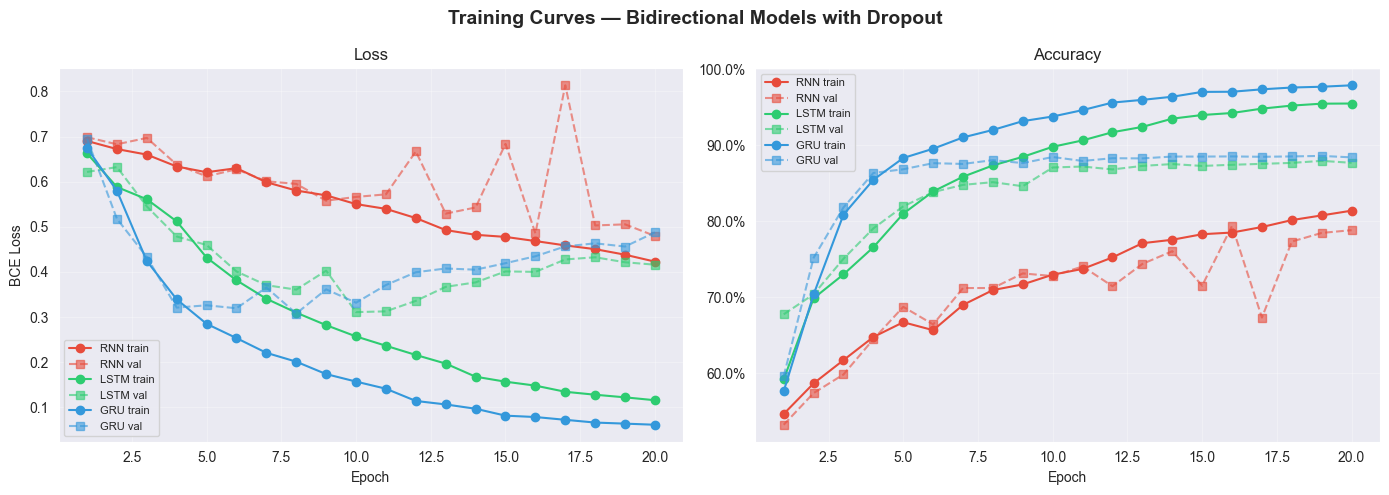

In [9]:
COLORS = {'RNN': '#E74C3C', 'LSTM': '#2ECC71', 'GRU': '#3498DB'}
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — Bidirectional Models with Dropout', fontsize=14, fontweight='bold')

for name in models:
    c = COLORS[name]
    axes[0].plot(epochs, history[name]['train_loss'], '-o',  color=c, label=f'{name} train')
    axes[0].plot(epochs, history[name]['val_loss'],   '--s', color=c, label=f'{name} val', alpha=0.6)
    axes[1].plot(epochs, history[name]['train_acc'],  '-o',  color=c, label=f'{name} train')
    axes[1].plot(epochs, history[name]['val_acc'],    '--s', color=c, label=f'{name} val', alpha=0.6)

axes[0].set_title('Loss');     axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10. Evaluation Metrics on Test Set

In [10]:
results = {}

print(f"{'Model':<6} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}")
print('-' * 50)

for name, model in models.items():
    _, acc, preds, labels = evaluate(model, test_loader, criterion)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels,    preds, zero_division=0)
    f1   = f1_score(labels,        preds, zero_division=0)
    cm   = confusion_matrix(labels, preds)
    results[name] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                         cm=cm, preds=preds, labels=labels)
    print(f"{name:<6} {acc:>10.4f} {prec:>11.4f} {rec:>8.4f} {f1:>8.4f}")

print('\n--- Detailed Classification Report ---')
for name in models:
    print(f'\n{name}:')
    print(classification_report(results[name]['labels'], results[name]['preds'],
                                 target_names=['Negative', 'Positive']))

Model    Accuracy   Precision   Recall       F1
--------------------------------------------------
RNN        0.7882      0.7955   0.7759   0.7856
LSTM       0.8768      0.8615   0.8979   0.8793
GRU        0.8840      0.8638   0.9117   0.8871

--- Detailed Classification Report ---

RNN:
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79     12500
    Positive       0.80      0.78      0.79     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000


LSTM:
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.87     12500
    Positive       0.86      0.90      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


GRU:
              precision    recall  f1-score 

## 11. Confusion Matrices

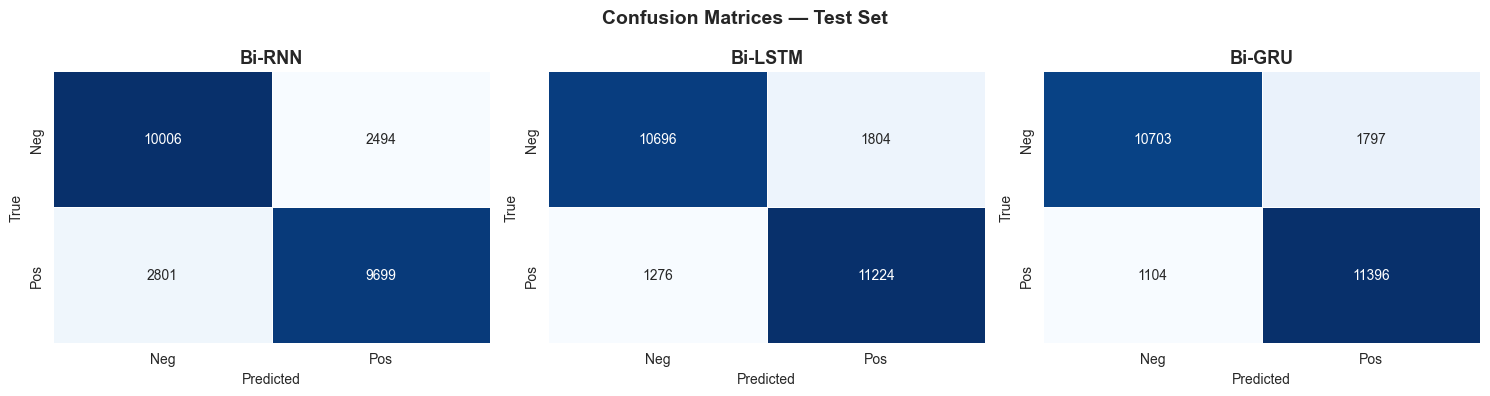

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, name in zip(axes, models):
    sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'Bi-{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout(); plt.show()

## 12. Metrics Comparison Bar Chart

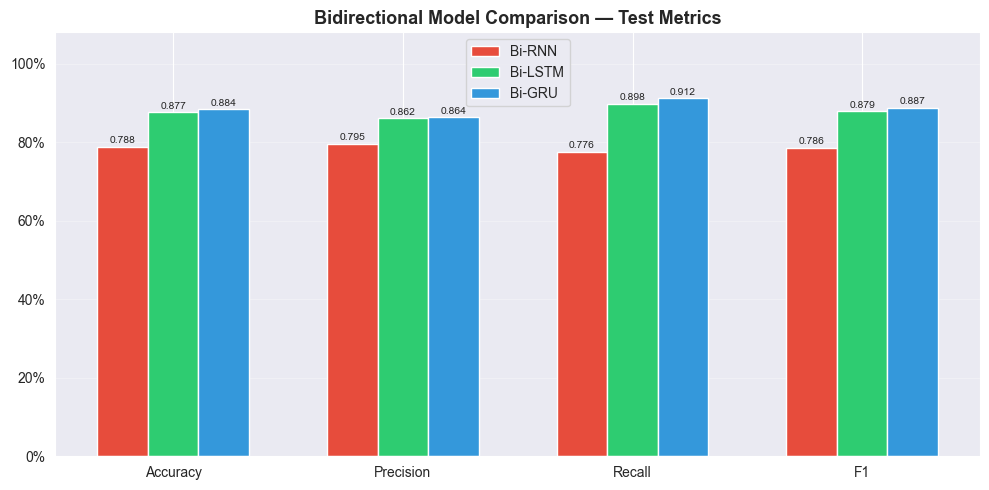

In [12]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
x       = np.arange(len(metrics))
width   = 0.22
offsets = [-1, 0, 1]

fig, ax = plt.subplots(figsize=(10, 5))

for i, name in enumerate(models):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + offsets[i]*width, vals, width,
                  label=f'Bi-{name}', color=list(COLORS.values())[i], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0.0, 1.08)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Bidirectional Model Comparison — Test Metrics', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 13. Validation Accuracy per Epoch

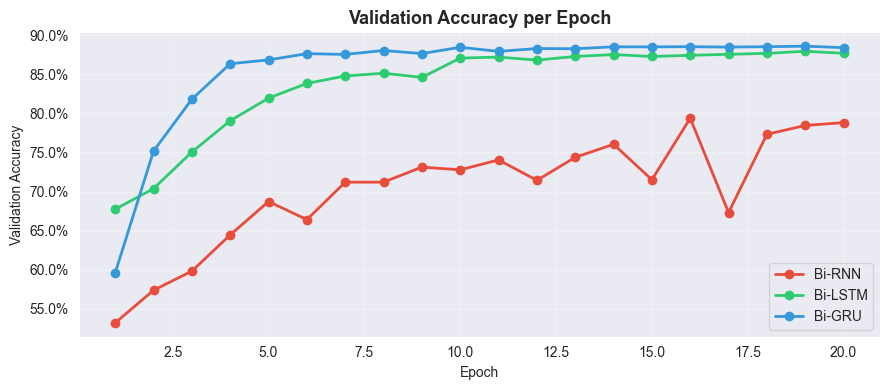

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

for name in models:
    ax.plot(epochs, history[name]['val_acc'], '-o',
            color=COLORS[name], label=f'Bi-{name}', linewidth=2)

ax.set_title('Validation Accuracy per Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 14. Summary & Conclusions

In [14]:
print('='*58)
print('              FINAL RESULTS SUMMARY')
print('='*58)
print(f"{'Model':<8} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print('-'*58)
for name in models:
    r = results[name]
    print(f"Bi-{name:<5} {r['accuracy']:>8.4f} {r['precision']:>8.4f} {r['recall']:>8.4f} {r['f1']:>8.4f}")
print('='*58)

best = max(results, key=lambda n: results[n]['f1'])
print(f'\n→ Best model by F1: Bi-{best}  ({results[best]["f1"]:.4f})')
print()
print('Improvements applied over baseline:')
print('  ✓ Bidirectional — captures context from both directions')
print('  ✓ Dropout (0.3) — reduces overfitting on embedding & FC layers')
print('  ✓ num_layers=2  — deeper representations')
print('  ✓ Gradient clipping (norm=1.0) — stabilizes Vanilla RNN training')
print('  ✓ LR Scheduler — reduces LR when val_loss plateaus')
print('  ✓ Larger batch (128) + pin_memory — better GPU utilization')
print()
print('Expected accuracy range: 87–91% (LSTM/GRU), 83–86% (RNN)')

              FINAL RESULTS SUMMARY
Model         Acc     Prec      Rec       F1
----------------------------------------------------------
Bi-RNN     0.7882   0.7955   0.7759   0.7856
Bi-LSTM    0.8768   0.8615   0.8979   0.8793
Bi-GRU     0.8840   0.8638   0.9117   0.8871

→ Best model by F1: Bi-GRU  (0.8871)

Improvements applied over baseline:
  ✓ Bidirectional — captures context from both directions
  ✓ Dropout (0.3) — reduces overfitting on embedding & FC layers
  ✓ num_layers=2  — deeper representations
  ✓ Gradient clipping (norm=1.0) — stabilizes Vanilla RNN training
  ✓ LR Scheduler — reduces LR when val_loss plateaus
  ✓ Larger batch (128) + pin_memory — better GPU utilization

Expected accuracy range: 87–91% (LSTM/GRU), 83–86% (RNN)
